In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
def get_price_plots(FILENAME: str, day: int) -> None:
    df = pd.read_csv(FILENAME, delimiter=';')
    root = df[df['product'] == 'INTARIAN_PEPPER_ROOT']
    osmium = df[df['product'] == 'ASH_COATED_OSMIUM']
    
    price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
    for col in price_cols:
        osmium[col] = osmium[col].replace(0, pd.NA)
        root[col] = root[col].replace(0, pd.NA)
    
    osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()
    root[price_cols] = root[root.columns.intersection(price_cols)].ffill()

    fig, ax = plt.subplots(figsize=(8, 5))
    plt.title(f'Day {day} Root Prices')
    ax.grid()
    ax.plot(root['timestamp'], root['bid_price_1'], color='red', label='Root Bid Price 1', alpha=0.5)

    ax.plot(root['timestamp'], root['ask_price_1'], color='green', label='Root Ask Price 1', alpha=0.5)

    ax.plot(root['timestamp'], root['mid_price'], linestyle='dashed', color='grey', label='Root Mid Price')
    plt.legend(loc='lower right')

    fig, ax = plt.subplots(figsize=(8, 5))
    plt.title(f'Day {day} Osmium Prices')
    ax.grid()
    ax.plot(osmium['timestamp'], osmium['bid_price_1'], color='red', label='Osmium Bid Price 1', alpha=0.5)

    ax.plot(osmium['timestamp'], osmium['ask_price_1'], color='green', label='Osmium Ask Price 1', alpha=0.5)

    ax.plot(osmium['timestamp'], osmium['mid_price'], linestyle='dashed', color='grey', label='Osmium Mid Price')
    plt.legend(loc='lower right')

C:\Users\wfpin\AppData\Local\Temp\ipykernel_38340\4243613686.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  osmium[col] = osmium[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_38340\4243613686.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  root[col] = root[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_38340\4243613686.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call resu

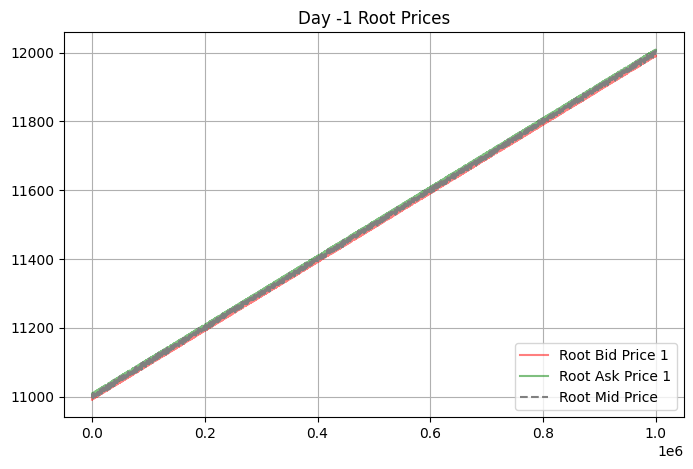

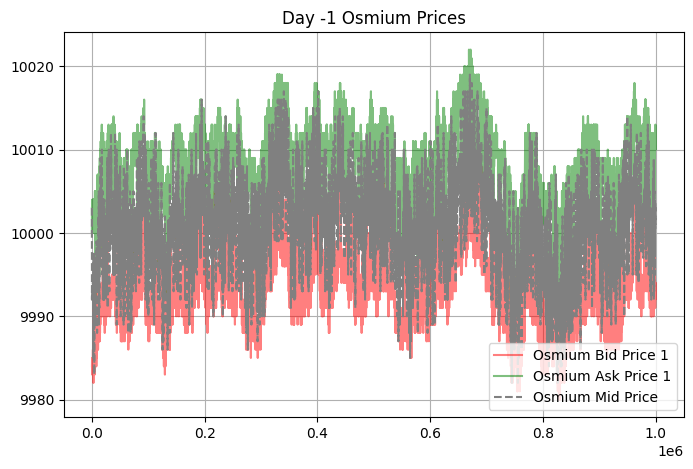

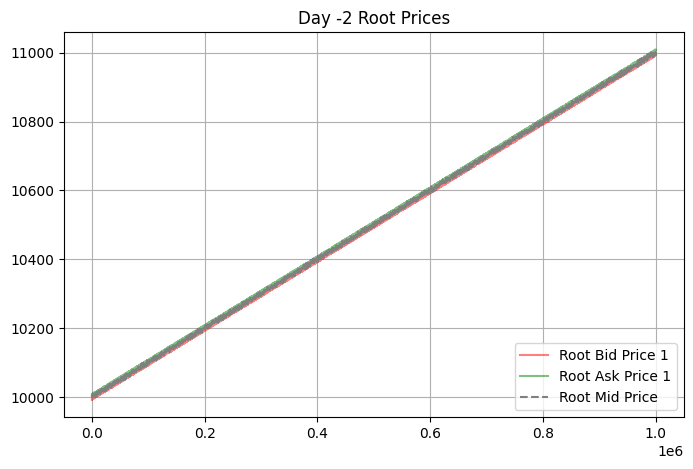

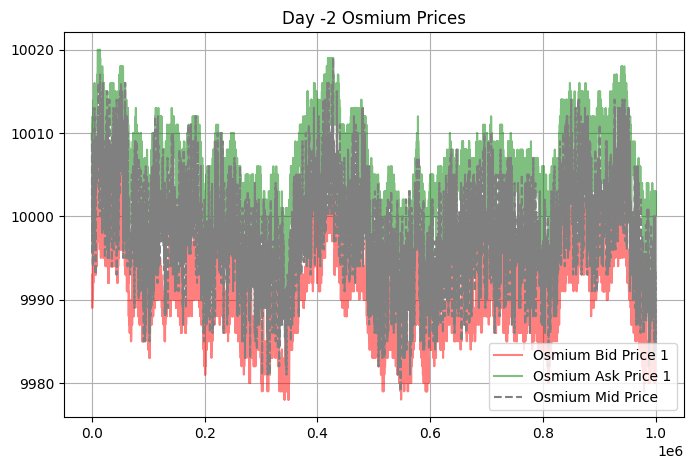

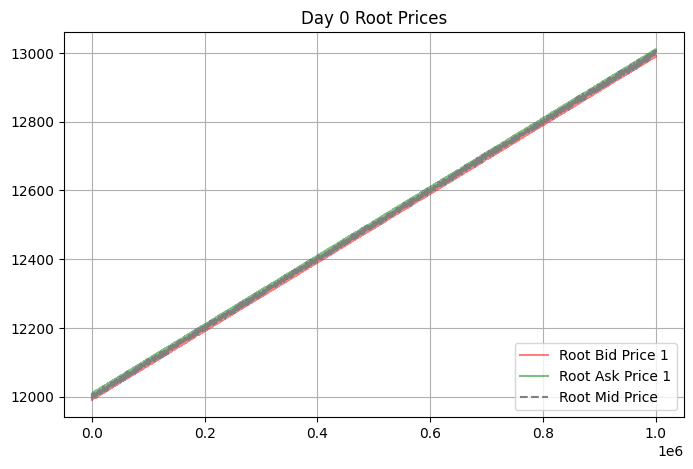

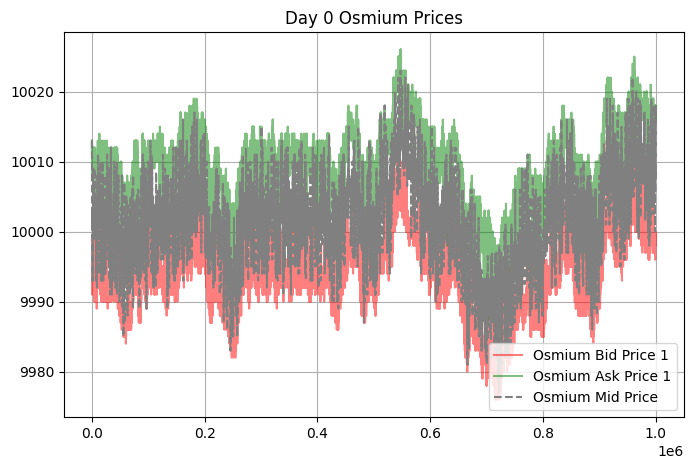

In [64]:
files = {-1: '../Round 1/Data/prices_round_1_day_-1.csv', 
         -2: '../Round 1/Data/prices_round_1_day_-2.csv', 
         0: '../Round 1/Data/prices_round_1_day_0.csv'}

for key, val in files.items():
    get_price_plots(FILENAME=val, day=key)